In [1]:
import numpy as np
import matplotlib.pyplot as plt

from graspologic.match import graph_match
import graspologic.match.wrappers as wrappers

from utils.Graphs import (
    gen_ER_graphs,
    gen_SBM_graphs,
    gen_correlated_powerlaw_graphs,
    gen_PAPER_graphs,
)

from utils.SeedingMethods import (
    random_seeds,
    blocked_random_seeds,
    highest_degree_seeds,
    blocked_highest_degree_seeds,
    betweenness_seeds,
    neighbor_degree_seeds,
    jaccard_neighborhood_seeds,
    spectral_unique_seeds,
)


# ============================================================
# RECORD THE INTERNAL SGM ITERATES
# ============================================================

last_solver = None


def solve_with_history(self, rng=None):
    """
    Temporary notebook-only replacement for the internal SGM solve method.

    It records:
        P_history_[i]     = relaxed iterate P^(i)
        Q_history_[i]     = Hungarian direction Q^(i)
        alpha_history_[i] = line-search coefficient alpha_i
    """
    global last_solver
    last_solver = self

    rng = np.random.default_rng(rng)

    self.n_iter_ = 0
    self.P_history_ = []
    self.Q_history_ = []
    self.alpha_history_ = []

    if self.n_seeds == self.n:
        P = np.empty((0, 0))
        self.converged_ = True

    else:
        # Initial relaxed matrix P^(0)
        P = self.initialize(rng)
        self.P_history_.append(P.copy())

        self.compute_constant_terms()

        for n_iter in range(self.max_iter):
            self.n_iter_ = n_iter + 1

            gradient = self.compute_gradient(P)

            # Hungarian/Frank-Wolfe direction Q^(i)
            Q = self.compute_step_direction(gradient, rng)

            # graspologic convention:
            # P^(i+1) = alpha_i P^(i) + (1-alpha_i) Q^(i)
            alpha = self.compute_step_size(P, Q)

            self.Q_history_.append(Q.copy())
            self.alpha_history_.append(float(alpha))

            P_new = alpha * P + (1.0 - alpha) * Q
            self.P_history_.append(P_new.copy())

            if self.check_converged(P, P_new):
                self.converged_ = True
                P = P_new
                break

            P = P_new

    self.finalize(P, rng)


# Apply the patch only to this notebook session
wrappers._GraphMatchSolver.solve = solve_with_history


# ============================================================
# CORRELATION HELPER
# ============================================================

def safe_correlation(x, y):
    """
    Pearson correlation, returning NaN when either variable is constant.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if len(x) < 2:
        return np.nan

    if np.isclose(np.std(x), 0) or np.isclose(np.std(y), 0):
        return np.nan

    return np.corrcoef(x, y)[0, 1]


# ============================================================
# RUN ONE EXPERIMENTAL REGIME
# ============================================================

def run_h0_experiment(
    graph_gen_func,
    seeding_func,
    n_seeds,
    n_trials=100,
    graph_kwargs=None,
    verbose=True,
):
    """
    Run repeated seeded graph-matching trials in one fixed regime.

    Parameters
    ----------
    graph_gen_func:
        One of the graph generators imported above.

    seeding_func:
        One of the seed-selection strategies imported above.

    n_seeds:
        Number of known seed correspondences.

    n_trials:
        Number of independently generated graph pairs.

    graph_kwargs:
        Dictionary of parameters passed to the graph generator.

    Returns
    -------
    records:
        One dictionary per trial.

    summary:
        Means and correlations across trials.
    """
    if graph_kwargs is None:
        graph_kwargs = {}

    records = []

    for trial in range(n_trials):

        G1, G2_shuffled, true_perm = graph_gen_func(**graph_kwargs)
        true_perm = np.asarray(true_perm, dtype=int)

        # Select seeds using the known true matching
        seeds_G1, seeds_G2 = seeding_func(
            G1,
            G2_shuffled,
            n_seeds,
            true_perm,
        )

        seeds_G1 = np.asarray(seeds_G1, dtype=int)
        seeds_G2 = np.asarray(seeds_G2, dtype=int)

        # Verify that the seed pairs are genuinely correct
        if not np.array_equal(seeds_G2, true_perm[seeds_G1]):
            raise ValueError(
                "The seed-selection function returned incorrect seed pairs."
            )

        partial_match = np.column_stack((seeds_G1, seeds_G2))

        # Run seeded graph matching
        result = graph_match(
            G1,
            G2_shuffled,
            partial_match=partial_match,
        )

        if last_solver is None:
            raise RuntimeError("The internal SGM solver was not recorded.")

        if len(last_solver.Q_history_) == 0:
            raise RuntimeError("No Frank-Wolfe direction was recorded.")

        # ====================================================
        # FIRST DIRECTION Q^(0)
        # ====================================================

        Q0 = last_solver.Q_history_[0]

        # The solver reorders vertices internally.
        # These recover the original G1 and G2 labels represented
        # by the rows and columns of Q0.
        rows_A = last_solver.perm_A[last_solver.n_seeds:]
        cols_B = last_solver.perm_B[last_solver.n_seeds:]

        # Since Q0 is a permutation matrix, each row has one chosen column
        predicted_column_positions = np.argmax(Q0, axis=1)
        predicted_B_from_Q0 = cols_B[predicted_column_positions]

        # True G2 matches of the corresponding G1 row labels
        true_B_for_rows = true_perm[rows_A]

        # First-direction match ratio on unseeded vertices
        H0 = np.mean(predicted_B_from_Q0 == true_B_for_rows)

        # ====================================================
        # FINAL SGM PERMUTATION
        # ====================================================

        predicted_perm = np.empty_like(true_perm)
        predicted_perm[result.indices_A] = result.indices_B

        all_vertices = np.arange(len(true_perm))

        unseeded_A = np.setdiff1d(
            all_vertices,
            seeds_G1,
            assume_unique=False,
        )

        final_unseeded = np.mean(
            predicted_perm[unseeded_A]
            == true_perm[unseeded_A]
        )

        final_all = np.mean(
            predicted_perm == true_perm
        )

        alpha0 = last_solver.alpha_history_[0]
        step_toward_Q0 = 1.0 - alpha0

        records.append(
            {
                "trial": trial + 1,
                "H0": float(H0),
                "final_unseeded": float(final_unseeded),
                "final_all": float(final_all),
                "alpha0": float(alpha0),
                "step_toward_Q0": float(step_toward_Q0),
                "n_iter": int(last_solver.n_iter_),
            }
        )

        if verbose:
            print(
                f"trial {trial + 1:>3}: "
                f"H0={H0:.4f}, "
                f"final_unseeded={final_unseeded:.4f}, "
                f"final_all={final_all:.4f}, "
                f"step_to_Q0={step_toward_Q0:.4f}"
            )

    H0_values = np.array(
        [record["H0"] for record in records]
    )

    final_unseeded_values = np.array(
        [record["final_unseeded"] for record in records]
    )

    final_all_values = np.array(
        [record["final_all"] for record in records]
    )

    alpha0_values = np.array(
        [record["alpha0"] for record in records]
    )

    correlation = safe_correlation(
        H0_values,
        final_unseeded_values,
    )

    summary = {
        "n_trials": n_trials,
        "mean_H0": float(np.mean(H0_values)),
        "std_H0": float(np.std(H0_values)),
        "mean_final_unseeded": float(
            np.mean(final_unseeded_values)
        ),
        "std_final_unseeded": float(
            np.std(final_unseeded_values)
        ),
        "mean_final_all": float(
            np.mean(final_all_values)
        ),
        "mean_alpha0": float(
            np.mean(alpha0_values)
        ),
        "correlation_H0_final_unseeded": float(correlation),
    }

    print("\nSummary")
    print("-------")
    print(f"Trials:                       {summary['n_trials']}")
    print(f"Mean H0:                      {summary['mean_H0']:.4f}")
    print(f"Standard deviation of H0:     {summary['std_H0']:.4f}")
    print(
        "Mean final unseeded ratio:   "
        f"{summary['mean_final_unseeded']:.4f}"
    )
    print(
        "Std. final unseeded ratio:   "
        f"{summary['std_final_unseeded']:.4f}"
    )
    print(
        "Mean final all-vertex ratio: "
        f"{summary['mean_final_all']:.4f}"
    )
    print(f"Mean alpha0:                  {summary['mean_alpha0']:.4f}")

    if np.isnan(correlation):
        print(
            "Correlation(H0, final):      NaN "
            "(one variable was constant)"
        )
    else:
        print(
            "Correlation(H0, final):      "
            f"{correlation:.4f}"
        )

    return records, summary


# ============================================================
# PLOT THE RESULT
# ============================================================

def plot_h0_vs_final(
    records,
    title="First-direction accuracy versus final SGM accuracy",
    add_linear_fit=True,
):
    """
    Scatterplot of H0 against final unseeded match ratio.

    The regression line is only a visual summary. The raw scatterplot
    remains important because the relationship may be threshold-like.
    """
    x = np.array(
        [record["H0"] for record in records],
        dtype=float,
    )

    y = np.array(
        [record["final_unseeded"] for record in records],
        dtype=float,
    )

    correlation = safe_correlation(x, y)

    plt.figure(figsize=(8, 6))
    plt.scatter(x, y, alpha=0.75)

    if (
        add_linear_fit
        and len(x) >= 2
        and not np.isclose(np.std(x), 0)
    ):
        slope, intercept = np.polyfit(x, y, 1)

        x_line = np.linspace(
            np.min(x),
            np.max(x),
            200,
        )

        y_line = slope * x_line + intercept

        plt.plot(
            x_line,
            y_line,
            linewidth=2,
            label="Least-squares line",
        )

        plt.legend()

    plt.xlabel(r"First-direction match ratio $H_0$")
    plt.ylabel("Final unseeded match ratio")

    if np.isnan(correlation):
        full_title = title + "\nPearson correlation undefined"
    else:
        full_title = (
            title
            + f"\nPearson correlation = {correlation:.4f}"
        )

    plt.title(full_title)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


print("Experiment code is ready.")

Experiment code is ready.


trial   1: H0=0.0964, final_unseeded=0.0571, final_all=0.1200, step_to_Q0=1.0000
trial   2: H0=0.0786, final_unseeded=0.0643, final_all=0.1267, step_to_Q0=1.0000
trial   3: H0=0.0464, final_unseeded=0.0321, final_all=0.0967, step_to_Q0=1.0000
trial   4: H0=0.0714, final_unseeded=0.0464, final_all=0.1100, step_to_Q0=1.0000
trial   5: H0=0.0536, final_unseeded=0.0321, final_all=0.0967, step_to_Q0=1.0000
trial   6: H0=0.0607, final_unseeded=0.0321, final_all=0.0967, step_to_Q0=1.0000
trial   7: H0=0.0607, final_unseeded=0.0429, final_all=0.1067, step_to_Q0=1.0000
trial   8: H0=0.0857, final_unseeded=0.0679, final_all=0.1300, step_to_Q0=1.0000
trial   9: H0=0.1071, final_unseeded=0.0464, final_all=0.1100, step_to_Q0=1.0000
trial  10: H0=0.0607, final_unseeded=0.0393, final_all=0.1033, step_to_Q0=1.0000
trial  11: H0=0.0607, final_unseeded=0.0429, final_all=0.1067, step_to_Q0=1.0000
trial  12: H0=0.0536, final_unseeded=0.0286, final_all=0.0933, step_to_Q0=1.0000
trial  13: H0=0.0821, final_

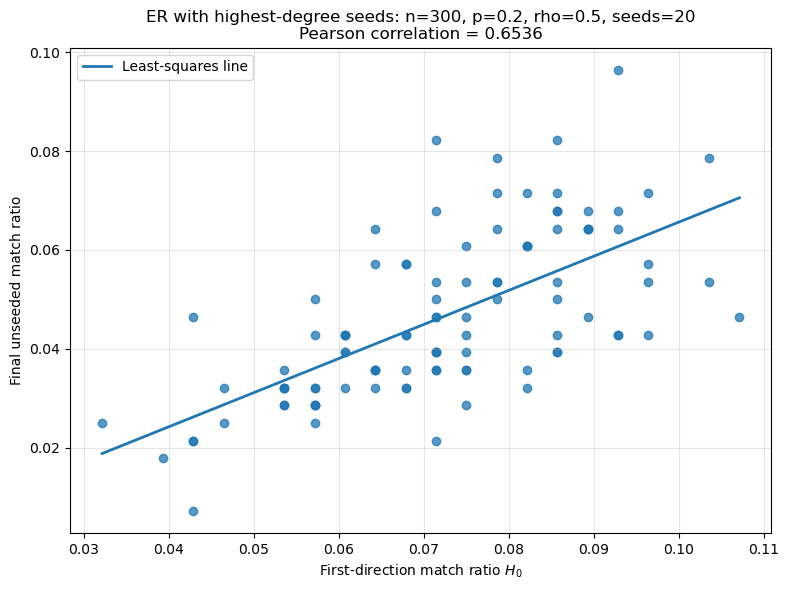

In [7]:
records, summary = run_h0_experiment(
    graph_gen_func=gen_ER_graphs,
    seeding_func=highest_degree_seeds,
    n_seeds=20,
    n_trials=100,
    graph_kwargs={
        "n": 300,
        "p": 0.2,
        "rho": 0.3,
    },
    verbose=True,
)

plot_h0_vs_final(
    records,
    title=(
        "ER with highest-degree seeds: "
        "n=300, p=0.2, rho=0.3, seeds=20"
    ),
)